**load the final feature dataset and frozen split**

In [6]:
import pandas as pd
import numpy as np

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent.resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

FEATURES_PATH = (
    PROJECT_ROOT
    / "data"
    / "features"
    / "sleep_edf_features.csv"
)

df = pd.read_csv(
    FEATURES_PATH
)

split_df = pd.read_csv(
    PROJECT_ROOT
    / "data"
    / "features"
    / "subject_split.csv"
)

df = df.merge(
    split_df,
    on="subject_id",
    how="inner",
    validate="many_to_one",
)

print(
    "Dataset:",
    df.shape
)

print(
    "Subjects:",
    df["subject_id"].nunique()
)

Dataset: (457577, 17)
Subjects: 197


**Recreate the normalized data**

In [5]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().parent.resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing.normalization import (
    SleepFeatureScaler,
)

from src.preprocessing.sequences import (
    find_contiguous_runs,
    build_sequences_from_dataframe,
    encode_sleep_stage_labels,
)

FEATURES_PATH = (
    PROJECT_ROOT
    / "data"
    / "features"
    / "sleep_edf_features.csv"
)

SPLIT_PATH = (
    PROJECT_ROOT
    / "data"
    / "features"
    / "subject_split.csv"
)

df = pd.read_csv(FEATURES_PATH)

split_df = pd.read_csv(SPLIT_PATH)

df_with_split = df.merge(
    split_df,
    on="subject_id",
    how="inner",
    validate="many_to_one",
)

train_df = (
    df_with_split[
        df_with_split["split"] == "train"
    ]
    .sort_values(
        ["subject_id", "start_time"]
    )
    .reset_index(drop=True)
)

val_df = (
    df_with_split[
        df_with_split["split"] == "val"
    ]
    .sort_values(
        ["subject_id", "start_time"]
    )
    .reset_index(drop=True)
)

test_df = (
    df_with_split[
        df_with_split["split"] == "test"
    ]
    .sort_values(
        ["subject_id", "start_time"]
    )
    .reset_index(drop=True)
)

feature_scaler = SleepFeatureScaler()

X_train_scaled = (
    feature_scaler.fit_transform(
        train_df
    )
)

X_val_scaled = (
    feature_scaler.transform(
        val_df
    )
)

X_test_scaled = (
    feature_scaler.transform(
        test_df
    )
)

print(
    X_train_scaled.shape,
    X_val_scaled.shape,
    X_test_scaled.shape,
)

(319628, 10) (69602, 10) (68347, 10)


**Calculate sequence-target counts per subject**

In [3]:
from src.preprocessing.sequences import (
    find_contiguous_runs,
)

SEQUENCE_LENGTH = 10

stage_order = [
    "W",
    "N1",
    "N2",
    "N3",
    "REM",
]

subject_sequence_counts = []

for subject_id, subject_df in (
    df.groupby("subject_id", sort=False)
):

    subject_df = (
        subject_df
        .sort_values("start_time")
        .reset_index(drop=True)
    )

    runs = find_contiguous_runs(
        subject_df
    )

    counts = {
        stage: 0
        for stage in stage_order
    }

    for run in runs:

        if len(run) < SEQUENCE_LENGTH:
            continue

        target_stages = (
            run["target_stage"]
            .iloc[
                SEQUENCE_LENGTH - 1:
            ]
        )

        counts.update({
            stage: counts[stage]
            + int(
                (target_stages == stage).sum()
            )
            for stage in stage_order
        })

    subject_sequence_counts.append(
        {
            "subject_id": subject_id,
            **counts,
        }
    )

subject_sequence_counts = pd.DataFrame(
    subject_sequence_counts
).set_index("subject_id")

print(
    "Subject sequence-target matrix:"
)

display(
    subject_sequence_counts.head(10)
)

Subject sequence-target matrix:


,W,N1,N2,N3,REM
subject_id,,,,,
SC4001,1988,58,250,220,125
SC4002,1876,59,373,288,215
SC4011,1847,109,562,105,170
SC4012,1815,92,660,96,176
SC4021,1898,94,545,95,163
SC4022,1862,179,399,119,178
SC4031,1999,61,485,57,209
SC4032,1948,45,400,131,199
SC4041,1525,164,620,53,189


**Compare the current split using sequence targets**

In [4]:
current_sequence_split = (
    subject_sequence_counts
    .join( # type: ignore
        split_df.set_index(
            "subject_id"
        )
    )
)

sequence_split_counts = (
    current_sequence_split
    .groupby("split")[
        stage_order
    ]
    .sum()
)

sequence_split_percentages = (
    sequence_split_counts.div(
        sequence_split_counts.sum(axis=1),
        axis=0,
    )
    * 100
)

print("Sequence target counts:")
display(
    sequence_split_counts
)

print(
    "\nSequence target percentages:"
)

display(
    sequence_split_percentages.round(2)
)

Sequence target counts:


,W,N1,N2,N3,REM
split,,,,,
test,43319,2946,13386,2858,5201
train,200350,18479,61809,12890,23472
val,44115,3417,12930,3672,5054



Sequence target percentages:


,W,N1,N2,N3,REM
split,,,,,
test,63.98,4.35,19.77,4.22,7.68
train,63.20,5.83,19.50,4.07,7.40
val,63.76,4.94,18.69,5.31,7.30


**Rebuild the sequences**

In [5]:
SEQUENCE_LENGTH = 10

X_train_seq, y_train_seq = (
    build_sequences_from_dataframe(
        dataframe=train_df,
        feature_values=X_train_scaled,
        sequence_length=SEQUENCE_LENGTH,
    )
)

X_val_seq, y_val_seq = (
    build_sequences_from_dataframe(
        dataframe=val_df,
        feature_values=X_val_scaled,
        sequence_length=SEQUENCE_LENGTH,
    )
)

X_test_seq, y_test_seq = (
    build_sequences_from_dataframe(
        dataframe=test_df,
        feature_values=X_test_scaled,
        sequence_length=SEQUENCE_LENGTH,
    )
)

print(
    "Training:",
    X_train_seq.shape,
)

print(
    "Validation:",
    X_val_seq.shape,
)

print(
    "Test:",
    X_test_seq.shape,
)

Training: (317000, 10, 10)
Validation: (69188, 10, 10)
Test: (67710, 10, 10)


**Check the corrected sequence distribution**

In [6]:
for split_name, targets in [
    ("Train", y_train_seq),
    ("Validation", y_val_seq),
    ("Test", y_test_seq),
]:

    counts = (
        pd.Series(targets)
        .value_counts()
        .reindex(
            [
                "W",
                "N1",
                "N2",
                "N3",
                "REM",
            ],
            fill_value=0,
        )
    )

    percentages = (
        counts
        / counts.sum()
        * 100
    )

    print(
        f"\n{split_name}"
    )

    print(
        pd.DataFrame({
            "count": counts,
            "percentage": percentages.round(2),
        })
    )


Train
      count  percentage
W    200350       63.20
N1    18479        5.83
N2    61809       19.50
N3    12890        4.07
REM   23472        7.40

Validation
     count  percentage
W    44115       63.76
N1    3417        4.94
N2   12930       18.69
N3    3672        5.31
REM   5054        7.30

Test
     count  percentage
W    43319       63.98
N1    2946        4.35
N2   13386       19.77
N3    2858        4.22
REM   5201        7.68


**Verify which split contains SC4002**

In [7]:
sc4002_split = split_df.loc[
    split_df["subject_id"] == "SC4002",
    "split",
]

print(
    "SC4002 split:"
)

print(
    sc4002_split
)

SC4002 split:
1    val
Name: split, dtype: str


**Verify SC4002 sequence construction independently**

In [8]:
sc4002_df = (
    df[
        df["subject_id"] == "SC4002"
    ]
    .sort_values("start_time")
    .reset_index(drop=True)
)

sc4002_features_raw = (
    feature_scaler.transform(
        sc4002_df
    )
)

X_sc4002, y_sc4002 = (
    build_sequences_from_dataframe(
        dataframe=sc4002_df,
        feature_values=sc4002_features_raw,
        sequence_length=10,
    )
)

print(
    "SC4002 epochs:",
    len(sc4002_df),
)

print(
    "SC4002 sequences:",
    X_sc4002.shape,
)

print(
    "First SC4002 target:",
    y_sc4002[0],
)

print(
    "\nFirst 10 source epochs:"
)

display(
    sc4002_df[
        [
            "epoch_index",
            "start_time",
            "end_time",
            "target_stage",
        ]
    ].head(10)
)

SC4002 epochs: 2829
SC4002 sequences: (2811, 10, 10)
First SC4002 target: W

First 10 source epochs:


,epoch_index,start_time,end_time,target_stage
0,0,0.0,30.0,W
1,1,30.0,60.0,W
2,2,60.0,90.0,W
3,3,90.0,120.0,W
4,4,120.0,150.0,W
5,5,150.0,180.0,W
6,6,180.0,210.0,W
7,7,210.0,240.0,W
8,8,240.0,270.0,W
9,9,270.0,300.0,W


**Verify sequence counts from actual generated targets**

In [9]:
for split_name, targets in [
    ("Train", y_train_seq),
    ("Validation", y_val_seq),
    ("Test", y_test_seq),
]:

    counts = (
        pd.Series(targets)
        .value_counts()
        .reindex(
            [
                "W",
                "N1",
                "N2",
                "N3",
                "REM",
            ],
            fill_value=0,
        )
    )

    print(
        f"\n{split_name} total sequences:",
        len(targets),
    )

    print(counts)


Train total sequences: 317000
W      200350
N1      18479
N2      61809
N3      12890
REM     23472
Name: count, dtype: int64

Validation total sequences: 69188
W      44115
N1      3417
N2     12930
N3      3672
REM     5054
Name: count, dtype: int64

Test total sequences: 67710
W      43319
N1      2946
N2     13386
N3      2858
REM     5201
Name: count, dtype: int64


**Final training class weights**

In [10]:
from sklearn.utils.class_weight import compute_class_weight
from src.preprocessing.sequences import (
    CLASS_LABELS
)

class_indices = np.arange(5)

y_train = encode_sleep_stage_labels(
    y_train_seq
)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=class_indices,
    y=y_train,
)

class_weights = {
    int(class_index): float(weight)
    for class_index, weight
    in zip(
        class_indices,
        class_weights_array,
    )
}

print("Final baseline class weights:")

for class_index, weight in class_weights.items():
    print(
        f"{CLASS_LABELS[class_index]:>3} "
        f"(class {class_index}): "
        f"{weight:.4f}"
    )

Final baseline class weights:
  W (class 0): 0.3164
 N1 (class 1): 3.4309
 N2 (class 2): 1.0257
 N3 (class 3): 4.9185
REM (class 4): 2.7011


**Create TensorFlow datasets for the corrected sequences**

In [11]:
import tensorflow as tf

BATCH_SIZE = 256

train_dataset = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            X_train_seq,
            y_train,
        )
    )
    .shuffle(
        buffer_size=10000,
        seed=42,
        reshuffle_each_iteration=True,
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

y_val = encode_sleep_stage_labels(
    y_val_seq
)

y_test = encode_sleep_stage_labels(
    y_test_seq
)

val_dataset = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            X_val_seq,
            y_val,
        )
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            X_test_seq,
            y_test,
        )
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Corrected TensorFlow datasets created.")

Corrected TensorFlow datasets created.


**Build the corrected baseline LSTM**

In [12]:
from src.models.lstm import (
    build_baseline_lstm,
    compile_baseline_lstm,
)

model = build_baseline_lstm(
    sequence_length=10,
    n_features=10,
    n_classes=5,
    lstm_units=64,
    dropout_rate=0.30,
)

model = compile_baseline_lstm(
    model,
    learning_rate=1e-3,
)

model.summary()

Model: "baseline_sleep_stage_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ eeg_features (InputLayer)       │ (None, 10, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sleep_stage (Dense)             │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,525 (76.27 KB)

 Trainable params: 19,525 (76.27 KB)

 Non-trainable params: 0 (0.00 B)

**Train corrected baseline LSTM**

In [13]:
from tensorflow import keras

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/30


d:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1239/1239 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.7641 - loss: 0.6984 - val_accuracy: 0.5475 - val_loss: 1.4227 - learning_rate: 0.0010
Epoch 2/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.8035 - loss: 0.6072 - val_accuracy: 0.6246 - val_loss: 1.2093 - learning_rate: 0.0010
Epoch 3/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.8126 - loss: 0.5755 - val_accuracy: 0.6081 - val_loss: 1.2680 - learning_rate: 0.0010
Epoch 4/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.8176 - loss: 0.5597 - val_accuracy: 0.6292 - val_loss: 1.1858 - learning_rate: 0.0010
Epoch 5/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.8228 - loss: 0.5453 - val_accuracy: 0.6524 - val_loss: 1.0974 - learning_rate: 0.0010
Epoch 6/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.8277 - loss: 0.5337 - val_accuracy: 0.6628 - val_loss: 1.0698 - learning_rate: 0.0010
Epoch 7/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.8303 

**Evaluate corrected baseline**

In [14]:
print("Validation:")
val_results = model.evaluate(
    val_dataset,
    verbose=1,
    return_dict=True,
)

print("\nTest:")
test_results = model.evaluate(
    test_dataset,
    verbose=1,
    return_dict=True,
)

print("\nValidation results:")
print(val_results)

print("\nTest results:")
print(test_results)

Validation:
271/271 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7605 - loss: 0.6633

Test:
265/265 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7838 - loss: 0.5920

Validation results:
{'accuracy': 0.7604931592941284, 'loss': 0.6632551550865173}

Test results:
{'accuracy': 0.7837985754013062, 'loss': 0.5919752717018127}


**Generate corrected test predictions**

In [15]:
test_probabilities = model.predict(
    test_dataset,
    verbose=1,
)

y_test_pred = np.argmax(
    test_probabilities,
    axis=1,
)

print(
    "Prediction shape:",
    y_test_pred.shape,
)

print(
    "Expected shape:",
    y_test.shape,
)

265/265 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
Prediction shape: (67710,)
Expected shape: (67710,)


**Corrected test classification report**

In [16]:
from sklearn.metrics import (
    classification_report,
)

class_names = [
    "W",
    "N1",
    "N2",
    "N3",
    "REM",
]

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

           W     0.9947    0.8457    0.9142     43319
          N1     0.2529    0.6850    0.3695      2946
          N2     0.7301    0.5840    0.6489     13386
          N3     0.6094    0.8446    0.7080      2858
         REM     0.5084    0.8047    0.6231      5201

    accuracy                         0.7838     67710
   macro avg     0.6191    0.7528    0.6527     67710
weighted avg     0.8565    0.7838    0.8070     67710



**Corrected baseline metrics**

In [17]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

accuracy = accuracy_score(
    y_test,
    y_test_pred,
)

balanced_accuracy = (
    balanced_accuracy_score(
        y_test,
        y_test_pred,
    )
)

macro_precision = (
    precision_score(
        y_test,
        y_test_pred,
        average="macro",
        zero_division=0,
    )
)

macro_recall = (
    recall_score(
        y_test,
        y_test_pred,
        average="macro",
        zero_division=0,
    )
)

macro_f1 = (
    f1_score(
        y_test,
        y_test_pred,
        average="macro",
        zero_division=0,
    )
)

weighted_f1 = (
    f1_score(
        y_test,
        y_test_pred,
        average="weighted",
        zero_division=0,
    )
)

print(
    f"Accuracy:          {accuracy:.4f}"
)

print(
    f"Balanced accuracy: {balanced_accuracy:.4f}"
)

print(
    f"Macro precision:   {macro_precision:.4f}"
)

print(
    f"Macro recall:      {macro_recall:.4f}"
)

print(
    f"Macro F1:          {macro_f1:.4f}"
)

print(
    f"Weighted F1:       {weighted_f1:.4f}"
)

Accuracy:          0.7838
Balanced accuracy: 0.7528
Macro precision:   0.6191
Macro recall:      0.7528
Macro F1:          0.6527
Weighted F1:       0.8070


**Corrected baseline confusion matrix**

Confusion matrix:
[[36637  3164  2084   533   901]
 [   69  2018   298     9   552]
 [   82  1915  7817  1004  2568]
 [   28    57   334  2414    25]
 [   17   824   174     1  4185]]


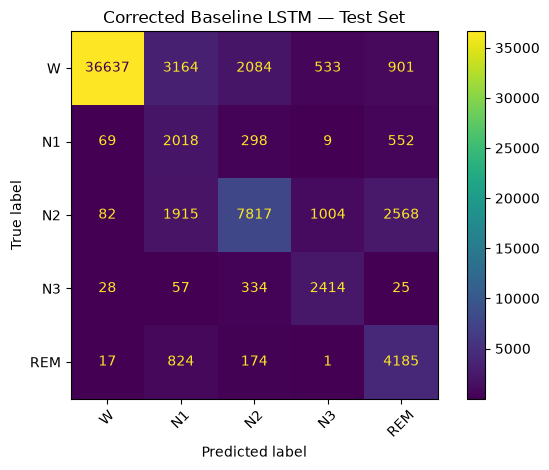

In [18]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_test_pred,
)

print("Confusion matrix:")
print(cm)

cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names,
)

cm_display.plot(
    xticks_rotation=45,
)

plt.title(
    "Corrected Baseline LSTM — Test Set"
)

plt.tight_layout()
plt.show()

**Save corrected weighted baseline**

In [19]:
BASELINE_DIR = (
    PROJECT_ROOT
    / "experiments"
    / "baseline_lstm"
)

BASELINE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

BASELINE_MODEL_PATH = (
    BASELINE_DIR
    / "weighted_lstm.keras"
)

BASELINE_HISTORY_PATH = (
    BASELINE_DIR
    / "weighted_history.csv"
)

model.save(
    BASELINE_MODEL_PATH
)

pd.DataFrame(
    history.history
).to_csv(
    BASELINE_HISTORY_PATH,
    index=False,
)

print(
    "Model saved to:",
    BASELINE_MODEL_PATH,
)

print(
    "History saved to:",
    BASELINE_HISTORY_PATH,
)

Model saved to: D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\experiments\baseline_lstm\weighted_lstm.keras
History saved to: D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\experiments\baseline_lstm\weighted_history.csv


**Save weighted baseline metrics**

In [20]:
baseline_metrics = {
    "accuracy": accuracy,
    "balanced_accuracy": balanced_accuracy,
    "macro_precision": macro_precision,
    "macro_recall": macro_recall,
    "macro_f1": macro_f1,
    "weighted_f1": weighted_f1,
}

baseline_metrics_df = pd.DataFrame(
    [baseline_metrics]
)

BASELINE_METRICS_PATH = (
    BASELINE_DIR
    / "weighted_metrics.csv"
)

baseline_metrics_df.to_csv(
    BASELINE_METRICS_PATH,
    index=False,
)

print(
    "Metrics saved to:",
    BASELINE_METRICS_PATH,
)

Metrics saved to: D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\experiments\baseline_lstm\weighted_metrics.csv


**Experiment 2 — Build unweighted LSTM**

In [21]:
from src.models.lstm import (
    build_baseline_lstm,
    compile_baseline_lstm,
)

unweighted_model = build_baseline_lstm(
    sequence_length=10,
    n_features=10,
    n_classes=5,
    lstm_units=64,
    dropout_rate=0.30,
)

unweighted_model = compile_baseline_lstm(
    unweighted_model,
    learning_rate=1e-3,
)

unweighted_model.summary()

Model: "baseline_sleep_stage_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ eeg_features (InputLayer)       │ (None, 10, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sleep_stage (Dense)             │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,525 (76.27 KB)

 Trainable params: 19,525 (76.27 KB)

 Non-trainable params: 0 (0.00 B)

**Experiment 2 — Callbacks**

In [22]:
from tensorflow import keras

unweighted_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

**Experiment 2 — Train unweighted LSTM**

In [23]:
unweighted_history = unweighted_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=unweighted_callbacks,
    verbose=1,
)

Epoch 1/30


d:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1239/1239 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.8326 - loss: 0.4478 - val_accuracy: 0.6960 - val_loss: 0.8142 - learning_rate: 0.0010
Epoch 2/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.8605 - loss: 0.3743 - val_accuracy: 0.7230 - val_loss: 0.7507 - learning_rate: 0.0010
Epoch 3/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.8686 - loss: 0.3541 - val_accuracy: 0.7343 - val_loss: 0.7407 - learning_rate: 0.0010
Epoch 4/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.8744 - loss: 0.3371 - val_accuracy: 0.7597 - val_loss: 0.6830 - learning_rate: 0.0010
Epoch 5/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.8792 - loss: 0.3245 - val_accuracy: 0.7572 - val_loss: 0.6954 - learning_rate: 0.0010
Epoch 6/30
1235/1239 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8816 - loss: 0.3174
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.8815 - 

**Experiment 2 — Evaluation**

In [24]:
print("Validation:")
unweighted_val_results = (
    unweighted_model.evaluate(
        val_dataset,
        verbose=1,
        return_dict=True,
    )
)

print("\nTest:")
unweighted_test_results = (
    unweighted_model.evaluate(
        test_dataset,
        verbose=1,
        return_dict=True,
    )
)

print("\nValidation results:")
print(unweighted_val_results)

print("\nTest results:")
print(unweighted_test_results)

Validation:
271/271 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8360 - loss: 0.4414

Test:
265/265 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8532 - loss: 0.3956

Validation results:
{'accuracy': 0.8360120058059692, 'loss': 0.4414476752281189}

Test results:
{'accuracy': 0.8532417416572571, 'loss': 0.39559680223464966}


**Experiment 2 — Test predictions**

In [25]:
unweighted_test_probabilities = (
    unweighted_model.predict(
        test_dataset,
        verbose=1,
    )
)

unweighted_y_test_pred = np.argmax(
    unweighted_test_probabilities,
    axis=1,
)

print(
    "Prediction shape:",
    unweighted_y_test_pred.shape,
)

print(
    "Expected shape:",
    y_test.shape,
)

265/265 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Prediction shape: (67710,)
Expected shape: (67710,)


**Experiment 2 — Classification report**

In [26]:
from sklearn.metrics import (
    classification_report,
)

class_names = [
    "W",
    "N1",
    "N2",
    "N3",
    "REM",
]

print(
    classification_report(
        y_test,
        unweighted_y_test_pred,
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

           W     0.9640    0.9327    0.9481     43319
          N1     0.4065    0.3585    0.3810      2946
          N2     0.7215    0.7713    0.7455     13386
          N3     0.8112    0.6585    0.7269      2858
         REM     0.6252    0.7895    0.6978      5201

    accuracy                         0.8532     67710
   macro avg     0.7057    0.7021    0.6999     67710
weighted avg     0.8593    0.8532    0.8548     67710



**Experiment 2 — Evaluation metrics**

In [27]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

unweighted_accuracy = (
    accuracy_score(
        y_test,
        unweighted_y_test_pred,
    )
)

unweighted_balanced_accuracy = (
    balanced_accuracy_score(
        y_test,
        unweighted_y_test_pred,
    )
)

unweighted_macro_precision = (
    precision_score(
        y_test,
        unweighted_y_test_pred,
        average="macro",
        zero_division=0,
    )
)

unweighted_macro_recall = (
    recall_score(
        y_test,
        unweighted_y_test_pred,
        average="macro",
        zero_division=0,
    )
)

unweighted_macro_f1 = (
    f1_score(
        y_test,
        unweighted_y_test_pred,
        average="macro",
        zero_division=0,
    )
)

unweighted_weighted_f1 = (
    f1_score(
        y_test,
        unweighted_y_test_pred,
        average="weighted",
        zero_division=0,
    )
)

print(
    f"Accuracy:          "
    f"{unweighted_accuracy:.4f}"
)

print(
    f"Balanced accuracy: "
    f"{unweighted_balanced_accuracy:.4f}"
)

print(
    f"Macro precision:   "
    f"{unweighted_macro_precision:.4f}"
)

print(
    f"Macro recall:      "
    f"{unweighted_macro_recall:.4f}"
)

print(
    f"Macro F1:          "
    f"{unweighted_macro_f1:.4f}"
)

print(
    f"Weighted F1:       "
    f"{unweighted_weighted_f1:.4f}"
)

Accuracy:          0.8532
Balanced accuracy: 0.7021
Macro precision:   0.7057
Macro recall:      0.7021
Macro F1:          0.6999
Weighted F1:       0.8548


**Experiment 2 — Confusion matrix**

Confusion matrix:
[[40405   624  1856   146   288]
 [  660  1056   715     4   511]
 [  563   562 10324   288  1649]
 [   45     1   917  1882    13]
 [  242   355   498     0  4106]]


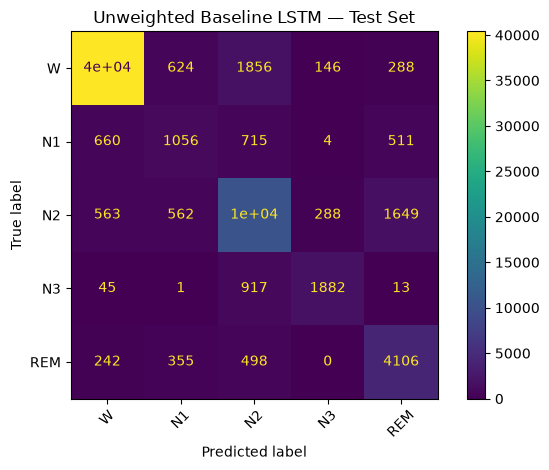

In [28]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

unweighted_cm = confusion_matrix(
    y_test,
    unweighted_y_test_pred,
)

print(
    "Confusion matrix:"
)

print(
    unweighted_cm
)

cm_display = ConfusionMatrixDisplay(
    confusion_matrix=unweighted_cm,
    display_labels=class_names,
)

cm_display.plot(
    xticks_rotation=45,
)

plt.title(
    "Unweighted Baseline LSTM — Test Set"
)

plt.tight_layout()
plt.show()

**Compare Experiment 1 vs Experiment 2**

In [29]:
comparison = pd.DataFrame(
    {
        "Weighted": [
            accuracy,
            balanced_accuracy,
            macro_precision,
            macro_recall,
            macro_f1,
            weighted_f1,
        ],
        "Unweighted": [
            unweighted_accuracy,
            unweighted_balanced_accuracy,
            unweighted_macro_precision,
            unweighted_macro_recall,
            unweighted_macro_f1,
            unweighted_weighted_f1,
        ],
    },
    index=[
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1",
    ],
)

display(
    comparison.round(4)
)

,Weighted,Unweighted
Accuracy,0.7838,0.8532
Balanced Accuracy,0.7528,0.7021
Macro Precision,0.6191,0.7057
Macro Recall,0.7528,0.7021
Macro F1,0.6527,0.6999
Weighted F1,0.8070,0.8548


**Experiment 3 — Moderated class weights**

In [30]:
moderated_class_weights = {
    class_index: float(np.sqrt(weight))
    for class_index, weight
    in class_weights.items()
}

print("Moderated class weights:")

for class_index, weight in moderated_class_weights.items():
    print(
        f"{CLASS_LABELS[class_index]:>3} "
        f"(class {class_index}): "
        f"{weight:.4f}"
    )

Moderated class weights:
  W (class 0): 0.5625
 N1 (class 1): 1.8523
 N2 (class 2): 1.0128
 N3 (class 3): 2.2178
REM (class 4): 1.6435


**Experiment 3 — Build moderated-weight LSTM**

In [31]:
moderated_model = build_baseline_lstm(
    sequence_length=10,
    n_features=10,
    n_classes=5,
    lstm_units=64,
    dropout_rate=0.30,
)

moderated_model = compile_baseline_lstm(
    moderated_model,
    learning_rate=1e-3,
)

**Experiment 3 — Train with moderated class weights**

In [32]:
moderated_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

moderated_history = moderated_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    class_weight=moderated_class_weights,
    callbacks=moderated_callbacks,
    verbose=1,
)

Epoch 1/30


d:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1239/1239 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.8173 - loss: 0.5392 - val_accuracy: 0.6346 - val_loss: 1.0135 - learning_rate: 0.0010
Epoch 2/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.8470 - loss: 0.4601 - val_accuracy: 0.6538 - val_loss: 0.9991 - learning_rate: 0.0010
Epoch 3/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.8555 - loss: 0.4361 - val_accuracy: 0.6947 - val_loss: 0.8755 - learning_rate: 0.0010
Epoch 4/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.8612 - loss: 0.4198 - val_accuracy: 0.6859 - val_loss: 0.9171 - learning_rate: 0.0010
Epoch 5/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.8640 - loss: 0.4106 - val_accuracy: 0.7153 - val_loss: 0.8220 - learning_rate: 0.0010
Epoch 6/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.8667 - loss: 0.4005 - val_accuracy: 0.7049 - val_loss: 0.8522 - learning_rate: 0.0010
Epoch 7/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.8700 

**Experiment 3 — Evaluation**

In [33]:
print("Validation:")
moderated_val_results = (
    moderated_model.evaluate(
        val_dataset,
        verbose=1,
        return_dict=True,
    )
)

print("\nTest:")
moderated_test_results = (
    moderated_model.evaluate(
        test_dataset,
        verbose=1,
        return_dict=True,
    )
)

print("\nValidation results:")
print(moderated_val_results)

print("\nTest results:")
print(moderated_test_results)

Validation:
271/271 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7847 - loss: 0.6043

Test:
265/265 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8085 - loss: 0.5259

Validation results:
{'accuracy': 0.7847170233726501, 'loss': 0.6042645573616028}

Test results:
{'accuracy': 0.8084625601768494, 'loss': 0.5259453058242798}


**Experiment 3 — Test predictions**

In [34]:
moderated_test_probabilities = (
    moderated_model.predict(
        test_dataset,
        verbose=1,
    )
)

moderated_y_test_pred = np.argmax(
    moderated_test_probabilities,
    axis=1,
)

print(
    "Prediction shape:",
    moderated_y_test_pred.shape,
)

print(
    "Expected shape:",
    y_test.shape,
)

265/265 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Prediction shape: (67710,)
Expected shape: (67710,)


**Experiment 3 — Classification report**

In [35]:
from sklearn.metrics import (
    classification_report,
)

class_names = [
    "W",
    "N1",
    "N2",
    "N3",
    "REM",
]

print(
    classification_report(
        y_test,
        moderated_y_test_pred,
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

           W     0.9876    0.8666    0.9231     43319
          N1     0.3122    0.5574    0.4002      2946
          N2     0.6726    0.7154    0.6933     13386
          N3     0.6600    0.6554    0.6577      2858
         REM     0.5583    0.7904    0.6544      5201

    accuracy                         0.8085     67710
   macro avg     0.6381    0.7170    0.6657     67710
weighted avg     0.8491    0.8085    0.8231     67710



**Experiment 3 — Evaluation metrics**

In [36]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

moderated_accuracy = (
    accuracy_score(
        y_test,
        moderated_y_test_pred,
    )
)

moderated_balanced_accuracy = (
    balanced_accuracy_score(
        y_test,
        moderated_y_test_pred,
    )
)

moderated_macro_precision = (
    precision_score(
        y_test,
        moderated_y_test_pred,
        average="macro",
        zero_division=0,
    )
)

moderated_macro_recall = (
    recall_score(
        y_test,
        moderated_y_test_pred,
        average="macro",
        zero_division=0,
    )
)

moderated_macro_f1 = (
    f1_score(
        y_test,
        moderated_y_test_pred,
        average="macro",
        zero_division=0,
    )
)

moderated_weighted_f1 = (
    f1_score(
        y_test,
        moderated_y_test_pred,
        average="weighted",
        zero_division=0,
    )
)

print(
    f"Accuracy:          "
    f"{moderated_accuracy:.4f}"
)

print(
    f"Balanced accuracy: "
    f"{moderated_balanced_accuracy:.4f}"
)

print(
    f"Macro precision:   "
    f"{moderated_macro_precision:.4f}"
)

print(
    f"Macro recall:      "
    f"{moderated_macro_recall:.4f}"
)

print(
    f"Macro F1:          "
    f"{moderated_macro_f1:.4f}"
)

print(
    f"Weighted F1:       "
    f"{moderated_weighted_f1:.4f}"
)

Accuracy:          0.8085
Balanced accuracy: 0.7170
Macro precision:   0.6381
Macro recall:      0.7170
Macro F1:          0.6657
Weighted F1:       0.8231


**Experiment 3 — Confusion matrix**

Confusion matrix:
[[37539  1528  2954   560   738]
 [  306  1642   469     6   523]
 [  127  1305  9576   399  1979]
 [   11    26   936  1873    12]
 [   29   759   302     0  4111]]


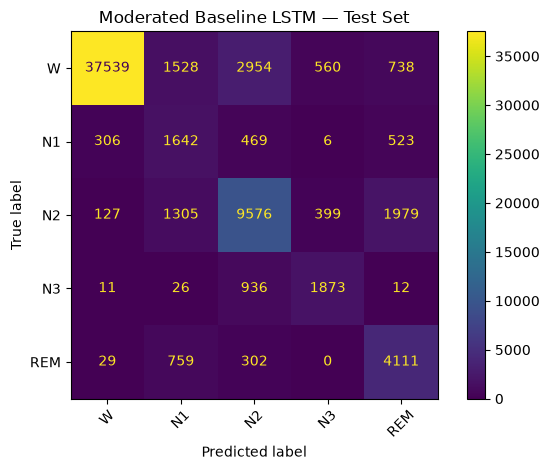

In [37]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

moderated_cm = confusion_matrix(
    y_test,
    moderated_y_test_pred,
)

print(
    "Confusion matrix:"
)

print(
    moderated_cm
)

cm_display = ConfusionMatrixDisplay(
    confusion_matrix=moderated_cm,
    display_labels=class_names,
)

cm_display.plot(
    xticks_rotation=45,
)

plt.title(
    "Moderated Baseline LSTM — Test Set"
)

plt.tight_layout()
plt.show()

**Compare Experiment 1 vs Experiment 2 vs Experiment 3**

In [38]:
comparison = pd.DataFrame(
    {
        "Weighted": [
            accuracy,
            balanced_accuracy,
            macro_precision,
            macro_recall,
            macro_f1,
            weighted_f1,
        ],
        "Unweighted": [
            unweighted_accuracy,
            unweighted_balanced_accuracy,
            unweighted_macro_precision,
            unweighted_macro_recall,
            unweighted_macro_f1,
            unweighted_weighted_f1,
        ],
        "Moderated:": [
            moderated_accuracy,
            moderated_balanced_accuracy,
            moderated_macro_precision,
            moderated_macro_recall,
            moderated_macro_f1,
            moderated_weighted_f1,
        ]
    },
    index=[
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1",
    ],
)

display(
    comparison.round(4)
)

,Weighted,Unweighted,Moderated:
Accuracy,0.7838,0.8532,0.8085
Balanced Accuracy,0.7528,0.7021,0.7170
Macro Precision,0.6191,0.7057,0.6381
Macro Recall,0.7528,0.7021,0.7170
Macro F1,0.6527,0.6999,0.6657
Weighted F1,0.8070,0.8548,0.8231


**Save the official unweighted baseline**

In [39]:
BASELINE_DIR = (
    PROJECT_ROOT
    / "experiments"
    / "baseline_lstm"
)

BASELINE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

BASELINE_MODEL_PATH = (
    BASELINE_DIR
    / "unweighted_lstm.keras"
)

BASELINE_HISTORY_PATH = (
    BASELINE_DIR
    / "unweighted_history.csv"
)

BASELINE_METRICS_PATH = (
    BASELINE_DIR
    / "unweighted_metrics.csv"
)

unweighted_model.save(
    BASELINE_MODEL_PATH
)

pd.DataFrame(
    unweighted_history.history
).to_csv(
    BASELINE_HISTORY_PATH,
    index=False,
)

baseline_metrics = pd.DataFrame(
    [{
        "accuracy": unweighted_accuracy,
        "balanced_accuracy": (
            unweighted_balanced_accuracy
        ),
        "macro_precision": (
            unweighted_macro_precision
        ),
        "macro_recall": (
            unweighted_macro_recall
        ),
        "macro_f1": (
            unweighted_macro_f1
        ),
        "weighted_f1": (
            unweighted_weighted_f1
        ),
    }]
)

baseline_metrics.to_csv(
    BASELINE_METRICS_PATH,
    index=False,
)

print("Baseline model:")
print(BASELINE_MODEL_PATH)

print("\nBaseline history:")
print(BASELINE_HISTORY_PATH)

print("\nBaseline metrics:")
print(BASELINE_METRICS_PATH)

Baseline model:
D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\experiments\baseline_lstm\unweighted_lstm.keras

Baseline history:
D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\experiments\baseline_lstm\unweighted_history.csv

Baseline metrics:
D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\experiments\baseline_lstm\unweighted_metrics.csv


**Reusable temporal-context experiment**

In [40]:
def train_temporal_model(
    X_train,
    y_train,
    X_val,
    y_val,
    sequence_length,
    experiment_name,
):
    """
    Train the same baseline LSTM architecture
    for a specified temporal context.
    """

    print(
        "=" * 70
    )
    print(
        f"Experiment: {experiment_name}"
    )
    print(
        f"Sequence length: "
        f"{sequence_length} epochs"
    )
    print(
        f"Temporal context: "
        f"{sequence_length * 30 / 60:.1f} minutes"
    )
    print(
        "=" * 70
    )

    model = build_baseline_lstm(
        sequence_length=sequence_length,
        n_features=10,
        n_classes=5,
        lstm_units=64,
        dropout_rate=0.30,
    )

    model = compile_baseline_lstm(
        model,
        learning_rate=1e-3,
    )

    batch_size = 256

    train_ds = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                X_train,
                y_train,
            )
        )
        .shuffle(
            buffer_size=10000,
            seed=42,
            reshuffle_each_iteration=True,
        )
        .batch(batch_size)
        .prefetch(
            tf.data.AUTOTUNE
        )
    )

    val_ds = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                X_val,
                y_val,
            )
        )
        .batch(batch_size)
        .prefetch(
            tf.data.AUTOTUNE
        )
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1,
        ),
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=30,
        callbacks=callbacks,
        verbose=1,
    )

    return (
        model,
        history,
    )

**Build 5-epoch sequences**

In [41]:
X_train_5, y_train_5 = (
    build_sequences_from_dataframe(
        dataframe=train_df,
        feature_values=X_train_scaled,
        sequence_length=5,
    )
)

X_val_5, y_val_5 = (
    build_sequences_from_dataframe(
        dataframe=val_df,
        feature_values=X_val_scaled,
        sequence_length=5,
    )
)

X_test_5, y_test_5 = (
    build_sequences_from_dataframe(
        dataframe=test_df,
        feature_values=X_test_scaled,
        sequence_length=5,
    )
)

y_train_5 = encode_sleep_stage_labels(
    y_train_5
)

y_val_5 = encode_sleep_stage_labels(
    y_val_5
)

y_test_5 = encode_sleep_stage_labels(
    y_test_5
)

print(
    "5-epoch sequences:"
)

print(
    "Train:",
    X_train_5.shape
)

print(
    "Validation:",
    X_val_5.shape
)

print(
    "Test:",
    X_test_5.shape
)

5-epoch sequences:
Train: (318437, 5, 10)
Validation: (69418, 5, 10)
Test: (68062, 5, 10)


**Build 20-epoch sequences**

In [9]:
X_train_20, y_train_20 = (
    build_sequences_from_dataframe(
        dataframe=train_df,
        feature_values=X_train_scaled,
        sequence_length=20,
    )
)

X_val_20, y_val_20 = (
    build_sequences_from_dataframe(
        dataframe=val_df,
        feature_values=X_val_scaled,
        sequence_length=20,
    )
)

X_test_20, y_test_20 = (
    build_sequences_from_dataframe(
        dataframe=test_df,
        feature_values=X_test_scaled,
        sequence_length=20,
    )
)

y_train_20 = encode_sleep_stage_labels(
    y_train_20
)

y_val_20 = encode_sleep_stage_labels(
    y_val_20
)

y_test_20 = encode_sleep_stage_labels(
    y_test_20
)

print(
    "20-epoch sequences:"
)

print(
    "Train:",
    X_train_20.shape
)

print(
    "Validation:",
    X_val_20.shape
)

print(
    "Test:",
    X_test_20.shape
)

20-epoch sequences:
Train: (314291, 20, 10)
Validation: (68730, 20, 10)
Test: (67017, 20, 10)


**Experiment: 2.5-minute context**

In [43]:
model_5, history_5 = (
    train_temporal_model(
        X_train_5,
        y_train_5,
        X_val_5,
        y_val_5,
        sequence_length=5,
        experiment_name="LSTM_5_epochs",
    )
)

Experiment: LSTM_5_epochs
Sequence length: 5 epochs
Temporal context: 2.5 minutes
Epoch 1/30


d:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1244/1244 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8162 - loss: 0.4947 - val_accuracy: 0.6913 - val_loss: 0.8309 - learning_rate: 0.0010
Epoch 2/30
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8445 - loss: 0.4140 - val_accuracy: 0.6830 - val_loss: 0.8664 - learning_rate: 0.0010
Epoch 3/30
1240/1244 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8503 - loss: 0.4010
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.8500 - loss: 0.4016 - val_accuracy: 0.6913 - val_loss: 0.8479 - learning_rate: 0.0010
Epoch 4/30
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8489 - loss: 0.4033 - val_accuracy: 0.6980 - val_loss: 0.8353 - learning_rate: 5.0000e-04
Epoch 5/30
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.8518 - loss: 0.3968 - val_accuracy: 0.7026 - val_loss: 0.8180 - learning_rate: 5.0000e-04
Epoch 6/30
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8537

**Experiment: 10-minute context**

In [44]:
model_20, history_20 = (
    train_temporal_model(
        X_train_20,
        y_train_20,
        X_val_20,
        y_val_20,
        sequence_length=20,
        experiment_name="LSTM_20_epochs",
    )
)

Experiment: LSTM_20_epochs
Sequence length: 20 epochs
Temporal context: 10.0 minutes
Epoch 1/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 37s 28ms/step - accuracy: 0.8410 - loss: 0.4302 - val_accuracy: 0.7514 - val_loss: 0.7006 - learning_rate: 0.0010
Epoch 2/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - accuracy: 0.8756 - loss: 0.3398 - val_accuracy: 0.7699 - val_loss: 0.6590 - learning_rate: 0.0010
Epoch 3/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - accuracy: 0.8839 - loss: 0.3149 - val_accuracy: 0.7837 - val_loss: 0.6218 - learning_rate: 0.0010
Epoch 4/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 31s 26ms/step - accuracy: 0.8894 - loss: 0.2992 - val_accuracy: 0.7878 - val_loss: 0.6407 - learning_rate: 0.0010
Epoch 5/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 29s 24ms/step - accuracy: 0.8927 - loss: 0.2900 - val_accuracy: 0.8024 - val_loss: 0.5802 - learning_rate: 0.0010
Epoch 6/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - accuracy: 0.8960 - loss: 0.2791 - val_accuracy: 0.8106 - val_loss: 0.5423 - l

**Evaluation helper**

In [13]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)


def evaluate_model(
    model,
    X_test,
    y_test,
    model_name,
):
    test_ds = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                X_test,
                y_test,
            )
        )
        .batch(256)
        .prefetch(
            tf.data.AUTOTUNE
        )
    )

    probabilities = model.predict(
        test_ds,
        verbose=1,
    )

    predictions = np.argmax(
        probabilities,
        axis=1,
    )

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(
            y_test,
            predictions,
        ),
        "balanced_accuracy": (
            balanced_accuracy_score(
                y_test,
                predictions,
            )
        ),
        "macro_precision": (
            precision_score(
                y_test,
                predictions,
                average="macro",
                zero_division=0,
            )
        ),
        "macro_recall": (
            recall_score(
                y_test,
                predictions,
                average="macro",
                zero_division=0,
            )
        ),
        "macro_f1": (
            f1_score(
                y_test,
                predictions,
                average="macro",
                zero_division=0,
            )
        ),
        "weighted_f1": (
            f1_score(
                y_test,
                predictions,
                average="weighted",
                zero_division=0,
            )
        ),
    }

    print(
        f"\n{model_name}"
    )

    for key, value in metrics.items():
        if key != "model":
            print(
                f"{key}: {value:.4f}"
            )

    return (
        metrics,
        predictions,
    )

**Evaluate temporal-context models**

In [46]:
metrics_5, pred_5 = evaluate_model(
    model_5,
    X_test_5,
    y_test_5,
    "LSTM — 5 epochs",
)

metrics_20, pred_20 = evaluate_model(
    model_20,
    X_test_20,
    y_test_20,
    "LSTM — 20 epochs",
)

266/266 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

LSTM — 5 epochs
accuracy: 0.8276
balanced_accuracy: 0.6657
macro_precision: 0.6619
macro_recall: 0.6657
macro_f1: 0.6554
weighted_f1: 0.8306
262/262 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step

LSTM — 20 epochs
accuracy: 0.8695
balanced_accuracy: 0.7051
macro_precision: 0.7268
macro_recall: 0.7051
macro_f1: 0.7109
weighted_f1: 0.8695


**Compare temporal contexts**

In [47]:
temporal_results = pd.DataFrame(
    [
        metrics_5,
        {
            "model": "LSTM — 10 epochs",
            "accuracy": unweighted_accuracy,
            "balanced_accuracy": (
                unweighted_balanced_accuracy
            ),
            "macro_precision": (
                unweighted_macro_precision
            ),
            "macro_recall": (
                unweighted_macro_recall
            ),
            "macro_f1": (
                unweighted_macro_f1
            ),
            "weighted_f1": (
                unweighted_weighted_f1
            ),
        },
        metrics_20,
    ]
)

display(
    temporal_results.round(4)
)

,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,LSTM — 5 epochs,0.8276,0.6657,0.6619,0.6657,0.6554,0.8306
1,LSTM — 10 epochs,0.8532,0.7021,0.7057,0.7021,0.6999,0.8548
2,LSTM — 20 epochs,0.8695,0.7051,0.7268,0.7051,0.7109,0.8695


**Reproducibility helper**

In [6]:
import random
import numpy as np
import tensorflow as tf


def set_experiment_seed(seed: int = 42):
    """
    Reset Python, NumPy, and TensorFlow random states.
    """

    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    print(
        f"Experiment seed set to {seed}"
    )

**Save the 20-epoch temporal model**

In [49]:
TEMPORAL_DIR = (
    PROJECT_ROOT
    / "experiments"
    / "temporal_context"
)

TEMPORAL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

model_20.save(
    TEMPORAL_DIR
    / "lstm_20_epochs.keras"
)

pd.DataFrame(
    history_20.history
).to_csv(
    TEMPORAL_DIR
    / "lstm_20_epochs_history.csv",
    index=False,
)

temporal_results.to_csv(
    TEMPORAL_DIR
    / "temporal_context_comparison.csv",
    index=False,
)

print(
    "Saved temporal-context experiment results."
)

Saved temporal-context experiment results.


**Flexible LSTM training function**

In [50]:
def train_capacity_model(
    X_train,
    y_train,
    X_val,
    y_val,
    sequence_length,
    lstm_units,
    experiment_name,
):
    """
    Train an unweighted LSTM while varying only
    the number of LSTM units.
    """

    print("=" * 70)
    print(f"Experiment: {experiment_name}")
    print(f"LSTM units: {lstm_units}")
    print(f"Sequence length: {sequence_length}")
    print(
        f"Temporal context: "
        f"{sequence_length * 30 / 60:.1f} minutes"
    )
    print("=" * 70)

    model = build_baseline_lstm(
        sequence_length=sequence_length,
        n_features=10,
        n_classes=5,
        lstm_units=lstm_units,
        dropout_rate=0.30,
    )

    model = compile_baseline_lstm(
        model,
        learning_rate=1e-3,
    )

    batch_size = 256

    train_ds = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                X_train,
                y_train,
            )
        )
        .shuffle(
            buffer_size=10000,
            seed=42,
            reshuffle_each_iteration=True,
        )
        .batch(batch_size)
        .prefetch(
            tf.data.AUTOTUNE
        )
    )

    val_ds = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                X_val,
                y_val,
            )
        )
        .batch(batch_size)
        .prefetch(
            tf.data.AUTOTUNE
        )
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1,
        ),
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=30,
        callbacks=callbacks,
        verbose=1,
    )

    return model, history

**Confirm 20-epoch dataset**

In [51]:
print(
    "Training:",
    X_train_20.shape,
    y_train_20.shape,
)

print(
    "Validation:",
    X_val_20.shape,
    y_val_20.shape,
)

print(
    "Test:",
    X_test_20.shape,
    y_test_20.shape,
)

Training: (314291, 20, 10) (314291,)
Validation: (68730, 20, 10) (68730,)
Test: (67017, 20, 10) (67017,)


**Experiment 5A: LSTM(32)**

In [52]:
set_experiment_seed(42)

model_32, history_32 = train_capacity_model(
    X_train=X_train_20,
    y_train=y_train_20,
    X_val=X_val_20,
    y_val=y_val_20,
    sequence_length=20,
    lstm_units=32,
    experiment_name="LSTM_20_epochs_32_units",
)

Experiment seed set to 42
Experiment: LSTM_20_epochs_32_units
LSTM units: 32
Sequence length: 20
Temporal context: 10.0 minutes
Epoch 1/30


d:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1228/1228 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.8233 - loss: 0.4777 - val_accuracy: 0.7257 - val_loss: 0.7146 - learning_rate: 0.0010
Epoch 2/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.8636 - loss: 0.3713 - val_accuracy: 0.7538 - val_loss: 0.6721 - learning_rate: 0.0010
Epoch 3/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.8743 - loss: 0.3422 - val_accuracy: 0.7733 - val_loss: 0.6507 - learning_rate: 0.0010
Epoch 4/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.8802 - loss: 0.3266 - val_accuracy: 0.7774 - val_loss: 0.6479 - learning_rate: 0.0010
Epoch 5/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.8839 - loss: 0.3159 - val_accuracy: 0.7757 - val_loss: 0.6767 - learning_rate: 0.0010
Epoch 6/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.8854 - loss: 0.3113 - val_accuracy: 0.7890 - val_loss: 0.6335 - learning_rate: 0.0010
Epoch 7/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.8883 

**Experiment 5B: LSTM(128)**

In [53]:
set_experiment_seed(42)

model_128, history_128 = train_capacity_model(
    X_train=X_train_20,
    y_train=y_train_20,
    X_val=X_val_20,
    y_val=y_val_20,
    sequence_length=20,
    lstm_units=128,
    experiment_name="LSTM_20_epochs_128_units",
)

Experiment seed set to 42
Experiment: LSTM_20_epochs_128_units
LSTM units: 128
Sequence length: 20
Temporal context: 10.0 minutes
Epoch 1/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 52s 41ms/step - accuracy: 0.8554 - loss: 0.3918 - val_accuracy: 0.7461 - val_loss: 0.7083 - learning_rate: 0.0010
Epoch 2/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 53s 43ms/step - accuracy: 0.8840 - loss: 0.3134 - val_accuracy: 0.7752 - val_loss: 0.6332 - learning_rate: 0.0010
Epoch 3/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 48s 39ms/step - accuracy: 0.8925 - loss: 0.2876 - val_accuracy: 0.7914 - val_loss: 0.5984 - learning_rate: 0.0010
Epoch 4/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 49s 40ms/step - accuracy: 0.8983 - loss: 0.2720 - val_accuracy: 0.8000 - val_loss: 0.5745 - learning_rate: 0.0010
Epoch 5/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 52s 42ms/step - accuracy: 0.9036 - loss: 0.2578 - val_accuracy: 0.8078 - val_loss: 0.5574 - learning_rate: 0.0010
Epoch 6/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 50s 41ms/step - accuracy: 0.9070 - loss: 0.2466 

**Evaluate LSTM(32)**

In [54]:
metrics_32, pred_32 = evaluate_model(
    model_32,
    X_test_20,
    y_test_20,
    "LSTM(32) — 20 epochs",
)

262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step

LSTM(32) — 20 epochs
accuracy: 0.8662
balanced_accuracy: 0.7004
macro_precision: 0.7251
macro_recall: 0.7004
macro_f1: 0.7081
weighted_f1: 0.8670


**Evaluate LSTM(128)**

In [55]:
metrics_128, pred_128 = evaluate_model(
    model_128,
    X_test_20,
    y_test_20,
    "LSTM(128) — 20 epochs",
)

262/262 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step

LSTM(128) — 20 epochs
accuracy: 0.8332
balanced_accuracy: 0.6656
macro_precision: 0.6722
macro_recall: 0.6656
macro_f1: 0.6546
weighted_f1: 0.8413


**Compare LSTM capacities**

In [56]:
capacity_results = pd.DataFrame(
    [
        metrics_32,
        {
            "model": "LSTM(64) — 20 epochs",
            "accuracy": 0.8602,
            "balanced_accuracy": 0.6985,
            "macro_precision": 0.7152,
            "macro_recall": 0.6985,
            "macro_f1": 0.7017,
            "weighted_f1": 0.8614,
        },
        metrics_128,
    ]
)

display(
    capacity_results.round(4)
)

,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,LSTM(32) — 20 epochs,0.8662,0.7004,0.7251,0.7004,0.7081,0.8670
1,LSTM(64) — 20 epochs,0.8602,0.6985,0.7152,0.6985,0.7017,0.8614
2,LSTM(128) — 20 epochs,0.8332,0.6656,0.6722,0.6656,0.6546,0.8413


**Save the best 32-unit / 20-epoch model**

In [57]:
CAPACITY_DIR = (
    PROJECT_ROOT
    / "experiments"
    / "lstm_capacity"
)

CAPACITY_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

model_32.save(
    CAPACITY_DIR
    / "lstm_32_units_20_epochs.keras"
)

pd.DataFrame(
    history_32.history
).to_csv(
    CAPACITY_DIR
    / "lstm_32_units_20_epochs_history.csv",
    index=False,
)

capacity_results.to_csv(
    CAPACITY_DIR
    / "capacity_comparison.csv",
    index=False,
)

best_capacity_metrics = pd.DataFrame(
    [
        metrics_32
    ]
)

best_capacity_metrics.to_csv(
    CAPACITY_DIR
    / "lstm_32_units_metrics.csv",
    index=False,
)

print(
    "Best capacity experiment saved."
)

Best capacity experiment saved.


**Train stacked LSTM**

In [18]:
from src.models.lstm import (
    build_stacked_lstm,
)

def train_stacked_lstm(
    X_train,
    y_train,
    X_val,
    y_val,
    sequence_length,
    lstm_units=32,
):
    set_experiment_seed(42)

    model = build_stacked_lstm(
        sequence_length=sequence_length,
        n_features=10,
        n_classes=5,
        lstm_units=lstm_units,
        dropout_rate=0.30,
    )

    model = compile_baseline_lstm(
        model,
        learning_rate=1e-3,
    )

    train_ds = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                X_train,
                y_train,
            )
        )
        .shuffle(
            buffer_size=10000,
            seed=42,
            reshuffle_each_iteration=True,
        )
        .batch(256)
        .prefetch(tf.data.AUTOTUNE)
    )

    val_ds = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                X_val,
                y_val,
            )
        )
        .batch(256)
        .prefetch(tf.data.AUTOTUNE)
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1,
        ),
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=30,
        callbacks=callbacks,
        verbose=1,
    )

    return model, history

**Inspect stacked LSTM**

In [59]:
stacked_test_model = build_stacked_lstm(
    sequence_length=20,
    n_features=10,
    n_classes=5,
    lstm_units=32,
    dropout_rate=0.30,
)

stacked_test_model.summary()

Model: "stacked_sleep_stage_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ eeg_features (InputLayer)       │ (None, 20, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 20, 32)         │         5,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sleep_stage (Dense)             │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,989 (54.64 KB)

 Trainable params: 13,989 (54.64 KB)

 Non-trainable params: 0 (0.00 B)

**Experiment 6: train stacked LSTM**

In [19]:
stacked_model, stacked_history = (
    train_stacked_lstm(
        X_train=X_train_20,
        y_train=y_train_20,
        X_val=X_val_20,
        y_val=y_val_20,
        sequence_length=20,
        lstm_units=32,
    )
)

Experiment seed set to 42
Epoch 1/30


d:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1228/1228 ━━━━━━━━━━━━━━━━━━━━ 35s 26ms/step - accuracy: 0.8338 - loss: 0.4529 - val_accuracy: 0.7311 - val_loss: 0.7183 - learning_rate: 0.0010
Epoch 2/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 30s 25ms/step - accuracy: 0.8722 - loss: 0.3499 - val_accuracy: 0.7670 - val_loss: 0.6671 - learning_rate: 0.0010
Epoch 3/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - accuracy: 0.8826 - loss: 0.3209 - val_accuracy: 0.7736 - val_loss: 0.6648 - learning_rate: 0.0010
Epoch 4/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - accuracy: 0.8888 - loss: 0.3026 - val_accuracy: 0.7877 - val_loss: 0.6308 - learning_rate: 0.0010
Epoch 5/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 30s 25ms/step - accuracy: 0.8937 - loss: 0.2882 - val_accuracy: 0.7874 - val_loss: 0.6458 - learning_rate: 0.0010
Epoch 6/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - accuracy: 0.8957 - loss: 0.2826 - val_accuracy: 0.7938 - val_loss: 0.6268 - learning_rate: 0.0010
Epoch 7/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - accuracy: 0.8981 

**Evaluate stacked LSTM**

In [20]:
stacked_metrics, stacked_predictions = (
    evaluate_model(
        stacked_model,
        X_test_20,
        y_test_20,
        "Stacked LSTM(32+32) — 20 epochs",
    )
)

262/262 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step

Stacked LSTM(32+32) — 20 epochs
accuracy: 0.8740
balanced_accuracy: 0.7039
macro_precision: 0.7345
macro_recall: 0.7039
macro_f1: 0.7146
weighted_f1: 0.8722


**Single-layer vs stacked LSTM**

In [62]:
stacked_comparison = pd.DataFrame(
    [
        metrics_32,
        stacked_metrics,
    ]
)

display(
    stacked_comparison.round(4)
)

,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,LSTM(32) — 20 epochs,0.8662,0.7004,0.7251,0.7004,0.7081,0.8670
1,Stacked LSTM(32+32) — 20 epochs,0.8740,0.7039,0.7345,0.7039,0.7146,0.8722


**Stacked LSTM classification report**

In [63]:
from sklearn.metrics import classification_report

class_names = [
    "W",
    "N1",
    "N2",
    "N3",
    "REM",
]

print(
    classification_report(
        y_test_20,
        stacked_predictions,
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

           W     0.9608    0.9615    0.9612     43009
          N1     0.4333    0.3383    0.3800      2891
          N2     0.7667    0.7907    0.7785     13160
          N3     0.8421    0.6480    0.7324      2855
         REM     0.6695    0.7809    0.7209      5102

    accuracy                         0.8740     67017
   macro avg     0.7345    0.7039    0.7146     67017
weighted avg     0.8727    0.8740    0.8722     67017



**Stacked LSTM confusion matrix**

Confusion matrix:
[[41353   418  1037    43   158]
 [  728   978   721     2   462]
 [  586   552 10405   302  1315]
 [   64     6   903  1850    32]
 [  309   303   506     0  3984]]


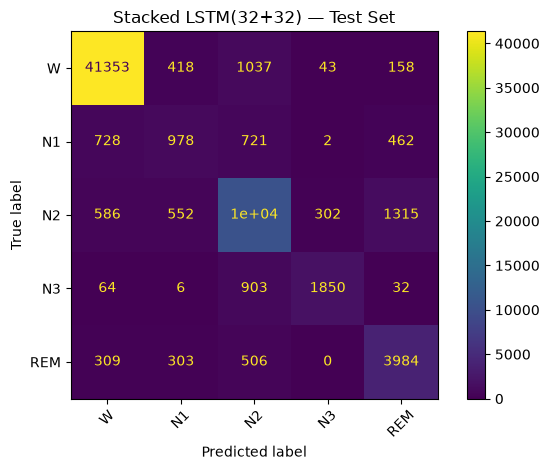

In [25]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

stacked_cm = confusion_matrix(
    y_test_20,
    stacked_predictions,
)

print("Confusion matrix:")
print(stacked_cm)

cm_display = ConfusionMatrixDisplay(
    confusion_matrix=stacked_cm,
    display_labels=class_names,
)

cm_display.plot(
    xticks_rotation=45,
)

plt.title(
    "Stacked LSTM(32+32) — Test Set"
)

plt.tight_layout()
plt.show()

**Save best stacked LSTM**

In [65]:
STACKED_DIR = (
    PROJECT_ROOT
    / "experiments"
    / "stacked_lstm"
)

STACKED_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

STACKED_MODEL_PATH = (
    STACKED_DIR
    / "stacked_lstm_32_32_20_epochs.keras"
)

STACKED_HISTORY_PATH = (
    STACKED_DIR
    / "stacked_lstm_32_32_20_epochs_history.csv"
)

STACKED_METRICS_PATH = (
    STACKED_DIR
    / "stacked_lstm_32_32_metrics.csv"
)

stacked_model.save(
    STACKED_MODEL_PATH
)

pd.DataFrame(
    stacked_history.history
).to_csv(
    STACKED_HISTORY_PATH,
    index=False,
)

pd.DataFrame(
    [stacked_metrics]
).to_csv(
    STACKED_METRICS_PATH,
    index=False,
)

print(
    "Model saved to:"
)

print(
    STACKED_MODEL_PATH
)

print(
    "\nHistory saved to:"
)

print(
    STACKED_HISTORY_PATH
)

print(
    "\nMetrics saved to:"
)

print(
    STACKED_METRICS_PATH
)

Model saved to:
D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\experiments\stacked_lstm\stacked_lstm_32_32_20_epochs.keras

History saved to:
D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\experiments\stacked_lstm\stacked_lstm_32_32_20_epochs_history.csv

Metrics saved to:
D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\experiments\stacked_lstm\stacked_lstm_32_32_metrics.csv


In [4]:
from src.models.lstm import (
    build_baseline_lstm,
    build_stacked_lstm,
    build_bidirectional_lstm,
    compile_baseline_lstm,
)

print(
    "LSTM model module imported successfully."
)

LSTM model module imported successfully.


**Train bidirectional LSTM**

In [10]:
from src.models.lstm import (
    build_bidirectional_lstm,
)

from tensorflow import keras

def train_bidirectional_lstm(
    X_train,
    y_train,
    X_val,
    y_val,
    sequence_length,
    lstm_units=32,
):
    set_experiment_seed(42)

    model = build_bidirectional_lstm(
        sequence_length=sequence_length,
        n_features=10,
        n_classes=5,
        lstm_units=lstm_units,
        dropout_rate=0.30,
    )

    model = compile_baseline_lstm(
        model,
        learning_rate=1e-3,
    )

    train_ds = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                X_train,
                y_train,
            )
        )
        .shuffle(
            buffer_size=10000,
            seed=42,
            reshuffle_each_iteration=True,
        )
        .batch(256)
        .prefetch(
            tf.data.AUTOTUNE
        )
    )

    val_ds = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                X_val,
                y_val,
            )
        )
        .batch(256)
        .prefetch(
            tf.data.AUTOTUNE
        )
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1,
        ),
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=30,
        callbacks=callbacks,
        verbose=1,
    )

    return model, history

**Inspect bidirectional LSTM**

In [6]:
bidirectional_test_model = (
    build_bidirectional_lstm(
        sequence_length=20,
        n_features=10,
        n_classes=5,
        lstm_units=32,
        dropout_rate=0.30,
    )
)

bidirectional_test_model.summary()

Model: "bidirectional_sleep_stage_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ eeg_features (InputLayer)       │ (None, 20, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_lstm_1            │ (None, 20, 64)         │        11,008 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_lstm_2            │ (None, 64)             │        24,832 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sleep_stage (Dense)             │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,165 (141.27 KB)

 Trainable params: 36,165 (141.27 KB)

 Non-trainable params: 0 (0.00 B)

**Experiment 7: train Bidirectional LSTM**

In [13]:
bidirectional_model, bidirectional_history = (
    train_bidirectional_lstm(
        X_train=X_train_20,
        y_train=y_train_20,
        X_val=X_val_20,
        y_val=y_val_20,
        sequence_length=20,
        lstm_units=32,
    )
)

Experiment seed set to 42
Epoch 1/30


d:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1228/1228 ━━━━━━━━━━━━━━━━━━━━ 63s 47ms/step - accuracy: 0.8497 - loss: 0.4120 - val_accuracy: 0.7705 - val_loss: 0.6343 - learning_rate: 0.0010
Epoch 2/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 64s 52ms/step - accuracy: 0.8782 - loss: 0.3306 - val_accuracy: 0.7849 - val_loss: 0.5995 - learning_rate: 0.0010
Epoch 3/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 71s 58ms/step - accuracy: 0.8877 - loss: 0.3038 - val_accuracy: 0.7877 - val_loss: 0.5949 - learning_rate: 0.0010
Epoch 4/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 73s 59ms/step - accuracy: 0.8932 - loss: 0.2873 - val_accuracy: 0.7859 - val_loss: 0.6023 - learning_rate: 0.0010
Epoch 5/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8974 - loss: 0.2757
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 69s 56ms/step - accuracy: 0.8974 - loss: 0.2757 - val_accuracy: 0.7913 - val_loss: 0.6066 - learning_rate: 0.0010
Epoch 6/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 54s 44ms/step - accuracy: 0.8986 - 

**Evaluate bidirectional LSTM**

In [16]:
bidirectional_metrics, bidirectional_predictions = (
    evaluate_model(
        bidirectional_model,
        X_test_20,
        y_test_20,
        "Bidirectional LSTM(32+32) — 20 epochs",
    )
)

262/262 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step

Bidirectional LSTM(32+32) — 20 epochs
accuracy: 0.8651
balanced_accuracy: 0.7067
macro_precision: 0.7128
macro_recall: 0.7067
macro_f1: 0.7070
weighted_f1: 0.8671


**Compare stacked vs bidirectional**

In [24]:
architecture_comparison = pd.DataFrame(
    [
        stacked_metrics,
        bidirectional_metrics,
    ]
)

display(
    architecture_comparison.round(4)
)

,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,Stacked LSTM(32+32) — 20 epochs,0.8740,0.7039,0.7345,0.7039,0.7146,0.8722
1,Bidirectional LSTM(32+32) — 20 epochs,0.8651,0.7067,0.7128,0.7067,0.7070,0.8671


**Save bidirectional LSTM experiment**

In [25]:
BIDIRECTIONAL_DIR = (
    PROJECT_ROOT
    / "experiments"
    / "bidirectional_lstm"
)

BIDIRECTIONAL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

bidirectional_model.save(
    BIDIRECTIONAL_DIR
    / "bidirectional_lstm_32_32_20_epochs.keras"
)

pd.DataFrame(
    bidirectional_history.history
).to_csv(
    BIDIRECTIONAL_DIR
    / "bidirectional_history.csv",
    index=False,
)

pd.DataFrame(
    [bidirectional_metrics]
).to_csv(
    BIDIRECTIONAL_DIR
    / "bidirectional_metrics.csv",
    index=False,
)

print(
    "Bidirectional experiment saved."
)

Bidirectional experiment saved.


**Inspect attention LSTM**

In [4]:
from src.models.lstm import (
    build_attention_lstm,
)

attention_test_model = (
    build_attention_lstm(
        sequence_length=20,
        n_features=10,
        n_classes=5,
        lstm_units=32,
        dropout_rate=0.30,
    )
)

attention_test_model.summary()

Model: "attention_sleep_stage_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ eeg_features (InputLayer)       │ (None, 20, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 20, 32)         │         5,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 20, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_attention              │ [(None, 32), (None,    │            33 │
│ (TemporalAttention)             │ 20)]                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sleep_stage (Dense)             │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,022 (54.77 KB)

 Trainable params: 14,022 (54.77 KB)

 Non-trainable params: 0 (0.00 B)

**Train attention LSTM**

In [11]:
from src.models.lstm import (
    compile_baseline_lstm,
)
from tensorflow import keras


set_experiment_seed(42)

attention_model = build_attention_lstm(
    sequence_length=20,
    n_features=10,
    n_classes=5,
    lstm_units=32,
    dropout_rate=0.30,
)

attention_model = compile_baseline_lstm(
    attention_model,
    learning_rate=1e-3,
)

attention_train_ds = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            X_train_20,
            y_train_20,
        )
    )
    .shuffle(
        buffer_size=10000,
        seed=42,
        reshuffle_each_iteration=True,
    )
    .batch(256)
    .prefetch(
        tf.data.AUTOTUNE
    )
)

attention_val_ds = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            X_val_20,
            y_val_20,
        )
    )
    .batch(256)
    .prefetch(
        tf.data.AUTOTUNE
    )
)

attention_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

attention_history = attention_model.fit(
    attention_train_ds,
    validation_data=attention_val_ds,
    epochs=30,
    callbacks=attention_callbacks,
    verbose=1,
)

Experiment seed set to 42
Epoch 1/30


d:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1228/1228 ━━━━━━━━━━━━━━━━━━━━ 42s 30ms/step - accuracy: 0.8196 - loss: 0.5017 - val_accuracy: 0.7314 - val_loss: 0.6841 - learning_rate: 0.0010
Epoch 2/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 36s 29ms/step - accuracy: 0.8597 - loss: 0.3843 - val_accuracy: 0.7452 - val_loss: 0.6552 - learning_rate: 0.0010
Epoch 3/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 36s 30ms/step - accuracy: 0.8719 - loss: 0.3503 - val_accuracy: 0.7601 - val_loss: 0.6189 - learning_rate: 0.0010
Epoch 4/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 37s 30ms/step - accuracy: 0.8787 - loss: 0.3331 - val_accuracy: 0.7668 - val_loss: 0.6243 - learning_rate: 0.0010
Epoch 5/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 36s 30ms/step - accuracy: 0.8845 - loss: 0.3160 - val_accuracy: 0.7809 - val_loss: 0.5934 - learning_rate: 0.0010
Epoch 6/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.8876 - loss: 0.3052 - val_accuracy: 0.7978 - val_loss: 0.5513 - learning_rate: 0.0010
Epoch 7/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 40s 32ms/step - accuracy: 0.8910 

**Evaluate attention LSTM**

In [14]:
attention_metrics, attention_predictions = (
    evaluate_model(
        attention_model,
        X_test_20,
        y_test_20,
        "Attention LSTM — 20 epochs",
    )
)

262/262 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step

Attention LSTM — 20 epochs
accuracy: 0.8452
balanced_accuracy: 0.6817
macro_precision: 0.6913
macro_recall: 0.6817
macro_f1: 0.6733
weighted_f1: 0.8506


**Compare attention against current winner**

In [21]:
attention_comparison = pd.DataFrame(
    [
        stacked_metrics,
        attention_metrics,
    ]
)

display(
    attention_comparison.round(4)
)

,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,Stacked LSTM(32+32) — 20 epochs,0.8740,0.7039,0.7345,0.7039,0.7146,0.8722
1,Attention LSTM — 20 epochs,0.8452,0.6817,0.6913,0.6817,0.6733,0.8506


**Save attention experiment**

In [22]:
ATTENTION_DIR = (
    PROJECT_ROOT
    / "experiments"
    / "attention_lstm"
)

ATTENTION_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

attention_model.save(
    ATTENTION_DIR
    / "attention_lstm_32_32_20_epochs.keras"
)

pd.DataFrame(
    attention_history.history
).to_csv(
    ATTENTION_DIR
    / "attention_history.csv",
    index=False,
)

pd.DataFrame(
    [attention_metrics]
).to_csv(
    ATTENTION_DIR
    / "attention_metrics.csv",
    index=False,
)

print(
    "Attention experiment saved."
)

Attention experiment saved.


**Final model classification report**

In [23]:
from sklearn.metrics import classification_report

final_classification_report = (
    classification_report(
        y_test_20,
        stacked_predictions,
        target_names=[
            "W",
            "N1",
            "N2",
            "N3",
            "REM",
        ],
        digits=4,
        zero_division=0,
        output_dict=True,
    )
)

final_report_df = pd.DataFrame(
    final_classification_report
).T

display(
    final_report_df.round(4)
)

,precision,recall,f1-score,support
W,0.9608,0.9615,0.9612,43009.000
N1,0.4333,0.3383,0.3800,2891.000
N2,0.7667,0.7907,0.7785,13160.000
N3,0.8421,0.6480,0.7324,2855.000
REM,0.6695,0.7809,0.7209,5102.000
accuracy,0.8740,0.8740,0.8740,0.874
macro avg,0.7345,0.7039,0.7146,67017.000
weighted avg,0.8727,0.8740,0.8722,67017.000


**Most common classification errors**

In [26]:
class_names = [
    "W",
    "N1",
    "N2",
    "N3",
    "REM",
]

error_rows = []

for true_class in range(5):

    for predicted_class in range(5):

        if true_class == predicted_class:
            continue

        count = stacked_cm[
            true_class,
            predicted_class,
        ]

        error_rows.append(
            {
                "true_stage": class_names[
                    true_class
                ],
                "predicted_stage": class_names[
                    predicted_class
                ],
                "count": int(count),
            }
        )

error_df = (
    pd.DataFrame(error_rows)
    .sort_values(
        "count",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    error_df.head(15)
)

,true_stage,predicted_stage,count
0,N2,REM,1315
1,W,N2,1037
2,N3,N2,903
3,N1,W,728
4,N1,N2,721
5,N2,W,586
6,N2,N1,552
7,REM,N2,506
8,N1,REM,462
9,W,N1,418


**N1 error analysis**

In [27]:
n1_mask = (
    y_test_20 == 1
)

n1_predictions = (
    stacked_predictions[
        n1_mask
    ]
)

n1_counts = (
    pd.Series(
        n1_predictions
    )
    .value_counts()
    .reindex(
        range(5),
        fill_value=0,
    )
)

n1_analysis = pd.DataFrame(
    {
        "predicted_stage": class_names,
        "count": n1_counts.values,
    }
)

n1_analysis["percentage"] = (
    n1_analysis["count"]
    / n1_analysis["count"].sum()
    * 100
)

display(
    n1_analysis.round(2)
)

,predicted_stage,count,percentage
0,W,728,25.18
1,N1,978,33.83
2,N2,721,24.94
3,N3,2,0.07
4,REM,462,15.98


**Analyze the stage immediately preceding each N1 target**

In [28]:
# Use the test dataframe in chronological order.
test_temporal = (
    test_df
    .sort_values(
        ["subject_id", "start_time"]
    )
    .reset_index(drop=True)
)

n1_rows = []

for _, subject_df in (
    test_temporal
    .groupby("subject_id", sort=False)
):

    subject_df = (
        subject_df
        .sort_values("start_time")
        .reset_index(drop=True)
    )

    for i in range(1, len(subject_df)):

        current_stage = (
            subject_df.loc[
                i,
                "target_stage",
            ]
        )

        if current_stage != "N1":
            continue

        previous_stage = (
            subject_df.loc[
                i - 1,
                "target_stage",
            ]
        )

        n1_rows.append(
            {
                "subject_id":
                    subject_df.loc[
                        i,
                        "subject_id",
                    ],
                "epoch_index":
                    subject_df.loc[
                        i,
                        "epoch_index",
                    ],
                "previous_stage":
                    previous_stage,
            }
        )

n1_transition_df = pd.DataFrame(
    n1_rows
)

print(
    "N1 targets with a preceding epoch:",
    len(n1_transition_df),
)

print(
    "\nPrevious-stage distribution:"
)

display(
    n1_transition_df[
        "previous_stage"
    ]
    .value_counts()
    .rename_axis(
        "previous_stage"
    )
    .to_frame("count")
)

N1 targets with a preceding epoch: 3003

Previous-stage distribution:


,count
previous_stage,
N1,2113
W,466
N2,286
REM,126
N3,12


**Correct vs incorrect N1 predictions**

In [29]:
n1_test_indices = np.where(
    y_test_20 == 1
)[0]

n1_prediction_values = (
    stacked_predictions[
        n1_test_indices
    ]
)

n1_results = pd.DataFrame(
    {
        "prediction":
            n1_prediction_values
    }
)

n1_results["correct"] = (
    n1_results["prediction"] == 1
)

print(
    "Correct N1 predictions:",
    n1_results["correct"].sum()
)

print(
    "Incorrect N1 predictions:",
    (~n1_results["correct"]).sum()
)

print(
    "\nN1 prediction distribution:"
)

display(
    n1_results[
        "prediction"
    ]
    .map(
        dict(
            enumerate(
                class_names
            )
        )
    )
    .value_counts()
)

Correct N1 predictions: 978
Incorrect N1 predictions: 1913

N1 prediction distribution:


prediction
N1     978
W      728
N2     721
REM    462
N3       2
Name: count, dtype: int64

**Build source metadata for test sequences**

In [3]:
def build_sequence_metadata(
    dataframe,
    sequence_length=20,
    time_tolerance=1e-6,
):
    """
    Return metadata describing the final target epoch
    of every generated temporal sequence.
    """

    metadata = []

    working_df = (
        dataframe
        .copy()
    )

    for subject_id, subject_df in (
        working_df
        .groupby(
            "subject_id",
            sort=False,
        )
    ):

        runs = find_contiguous_runs(
            subject_df,
            time_tolerance=time_tolerance,
        )

        for run in runs:

            if len(run) < sequence_length:
                continue

            positions = (
                run.index.to_numpy(
                    dtype=int
                )
            )

            for start in range(
                len(positions)
                - sequence_length
                + 1
            ):

                window = positions[
                    start:
                    start + sequence_length
                ]

                target_position = (
                    window[-1]
                )

                metadata.append(
                    {
                        "subject_id":
                            working_df.loc[
                                target_position,
                                "subject_id",
                            ],

                        "epoch_index":
                            working_df.loc[
                                target_position,
                                "epoch_index",
                            ],

                        "start_time":
                            working_df.loc[
                                target_position,
                                "start_time",
                            ],

                        "target_stage":
                            working_df.loc[
                                target_position,
                                "target_stage",
                            ],
                    }
                )

    return pd.DataFrame(
        metadata
    )

**Build metadata for test sequences**

In [8]:
test_sequence_metadata = (
    build_sequence_metadata(
        test_df,
        sequence_length=20,
    )
)

print(
    "Metadata shape:",
    test_sequence_metadata.shape,
)

print(
    "Expected sequences:",
    len(y_test_20),
)

print(
    "Metadata targets:",
    len(
        test_sequence_metadata
    ),
)

Metadata shape: (67017, 4)


NameError: name 'y_test_20' is not defined

**Align the predictions**

In [32]:
test_sequence_metadata[
    "prediction"
] = stacked_predictions

**N1 performance by preceding stage**

In [33]:
analysis_rows = []

for subject_id, subject_df in (
    test_df
    .sort_values(
        ["subject_id", "start_time"]
    )
    .groupby(
        "subject_id",
        sort=False,
    )
):

    subject_df = (
        subject_df
        .sort_values("start_time")
        .reset_index(drop=True)
    )

    for i in range(
        1,
        len(subject_df),
    ):

        if (
            subject_df.loc[
                i,
                "target_stage",
            ]
            != "N1"
        ):
            continue

        epoch_index = (
            subject_df.loc[
                i,
                "epoch_index",
            ]
        )

        previous_stage = (
            subject_df.loc[
                i - 1,
                "target_stage",
            ]
        )

        analysis_rows.append(
            {
                "subject_id":
                    subject_id,
                "epoch_index":
                    epoch_index,
                "previous_stage":
                    previous_stage,
            }
        )

n1_transition_info = pd.DataFrame(
    analysis_rows
)

n1_analysis = (
    test_sequence_metadata[
        test_sequence_metadata[
            "target_stage"
        ] == "N1"
    ]
    .merge(
        n1_transition_info,
        on=[
            "subject_id",
            "epoch_index",
        ],
        how="left",
    )
)

n1_analysis["correct"] = (
    n1_analysis[
        "prediction"
    ] == 1
)

transition_summary = (
    n1_analysis
    .groupby(
        "previous_stage"
    )["correct"]
    .agg(
        count="count",
        correct="sum",
    )
)

transition_summary[
    "accuracy"
] = (
    transition_summary["correct"]
    / transition_summary["count"]
)

display(
    transition_summary.round(4)
)

,count,correct,accuracy
previous_stage,,,
N1,2040,724,0.3549
N2,274,53,0.1934
N3,9,0,0.0000
REM,121,15,0.1240
W,447,186,0.4161


**Compare N1 feature distributions for correct and incorrect predictions**

In [7]:
FEATURE_COLUMNS = [
    "delta_absolute",
    "theta_absolute",
    "alpha_absolute",
    "beta_absolute",
    "delta_relative",
    "theta_relative",
    "alpha_relative",
    "beta_relative",
    "spectral_entropy",
    "dominant_frequency",
]

# Get the test epochs corresponding to the sequence targets.
test_target_metadata = (
    test_sequence_metadata[
        [
            "subject_id",
            "epoch_index",
            "prediction",
            "target_stage",
        ]
    ]
)

# Attach the original spectral features.
n1_feature_df = test_target_metadata.merge(
    test_df[
        [
            "subject_id",
            "epoch_index",
            *FEATURE_COLUMNS,
        ]
    ],
    on=[
        "subject_id",
        "epoch_index",
    ],
    how="left",
    validate="one_to_one",
)

# Keep only true N1 targets.
n1_feature_df = n1_feature_df[
    n1_feature_df["target_stage"] == "N1"
].copy()

n1_feature_df["prediction_type"] = np.where(
    n1_feature_df["prediction"] == 1,
    "Correct N1",
    "Incorrect N1",
)

print(
    "N1 samples:",
    len(n1_feature_df),
)

print(
    "\nPrediction types:"
)

print(
    n1_feature_df[
        "prediction_type"
    ].value_counts()
)

NameError: name 'test_sequence_metadata' is not defined

**N1 correct vs incorrect feature means**

In [ ]:
n1_feature_means = (
    n1_feature_df
    .groupby(
        "prediction_type"
    )[FEATURE_COLUMNS]
    .mean()
    .T
)

display(
    n1_feature_means
)

**N1 correct vs incorrect feature medians**

In [ ]:
n1_feature_medians = (
    n1_feature_df
    .groupby(
        "prediction_type"
    )[FEATURE_COLUMNS]
    .median()
    .T
)

display(
    n1_feature_medians
)

**Spectral profiles of N1 confusions**

In [ ]:
n1_confusion_groups = (
    n1_feature_df[
        n1_feature_df["prediction"].isin(
            [0, 1, 2, 4]
        )
    ]
    .copy()
)

n1_confusion_groups["prediction_label"] = (
    n1_confusion_groups[
        "prediction"
    ].map(
        {
            0: "Predicted W",
            1: "Predicted N1",
            2: "Predicted N2",
            4: "Predicted REM",
        }
    )
)

n1_profiles = (
    n1_confusion_groups
    .groupby(
        "prediction_label"
    )[FEATURE_COLUMNS]
    .mean()
    .T
)

display(
    n1_profiles
)